# Yolo runs

In [1]:
import pandas as pd 
import numpy as np 

import seaborn as sns 
import matplotlib.pyplot as plt 

from pathlib import Path 

In [2]:
FOLDER = Path('/home/leostre/Рабочий стол/SoftStairs-QAT/runs/detect')
baseline = 'train'

def read_data(run):
    return pd.read_csv(FOLDER / run / 'results.csv')

In [3]:
from itertools import product 

def compare_runs(run, baseline):
    drop_cols = ['time']
    run_df = read_data(run)#.set_index(['epoch'])
    baseline_df = read_data(baseline)#.set_index(['epoch'])

    # equal_epochs = min(len(run_df), len(baseline_df))
    # run_df = run_df.iloc[:equal_epochs]
    # baseline_df = baseline_df.iloc[:equal_epochs]

    # plot losses 

    fig, axes = plt.subplots(2, 3, sharex=True, figsize=(12, 10))
    axes = np.array(axes).flatten()
    for ax, (mode, loss_name) in zip(axes, product(['train', 'val'], ['box_loss', 'cls_loss', 'l1_loss'])):
        sns.lineplot(run_df, x='epoch', y=f'{mode}/{loss_name}', ax=ax, label=run)
        sns.lineplot(baseline_df, x='epoch', y=f'{mode}/{loss_name}', ax=ax, label=baseline)
        ax.grid()
    
    plt.show()

    # plot metrics

    fig, axes = plt.subplots(2, 2, sharex=True, figsize=(12, 10))
    axes = np.array(axes).flatten()
    for ax, (mode, loss_name) in zip(axes, product(['metrics'],  ['precision(B)', 'recall(B)', 'mAP50(B)', 'mAP50-95(B)'])):
        sns.lineplot(run_df, x='epoch', y=f'{mode}/{loss_name}', ax=ax, label=run)
        sns.lineplot(baseline_df, x='epoch', y=f'{mode}/{loss_name}', ax=ax, label=baseline)
        ax.grid()
    
    plt.show()



    

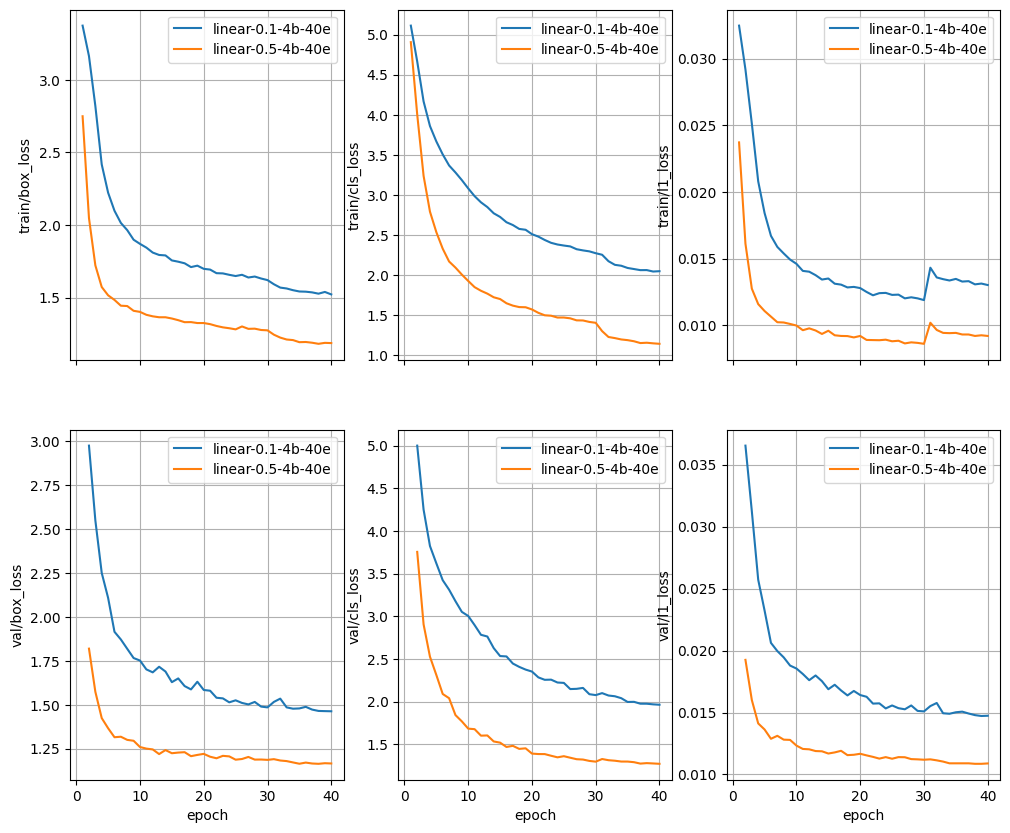

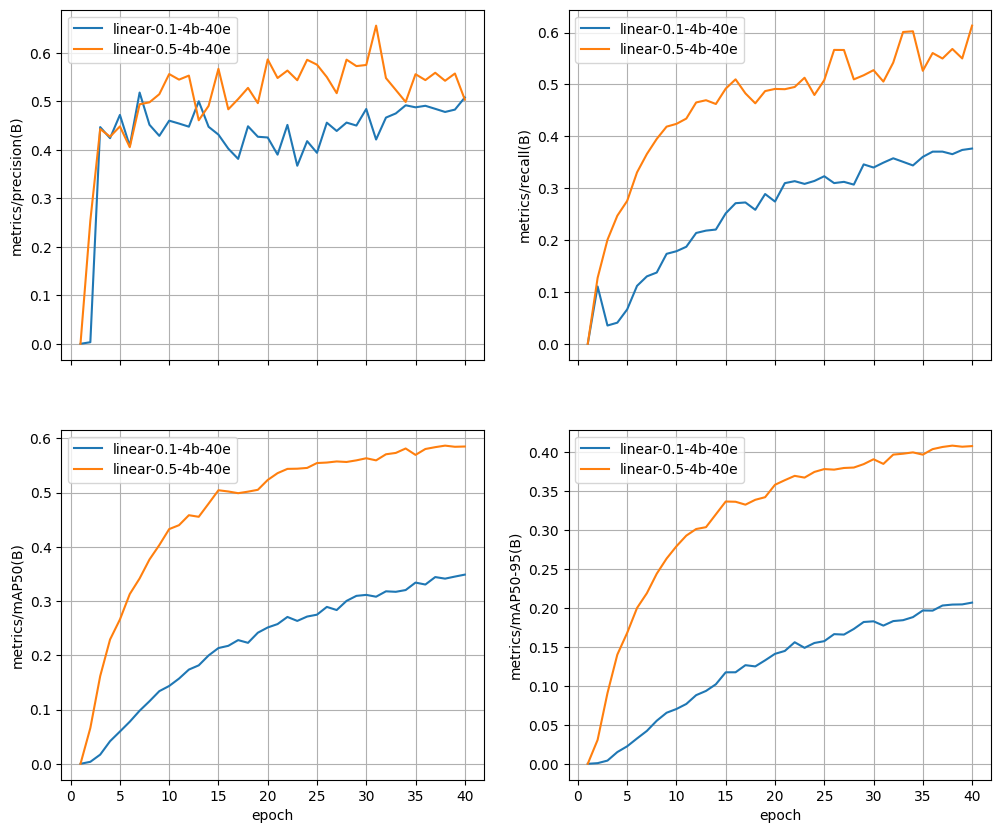

In [6]:
compare_runs(
     'linear-0.1-4b-40e',
    # 'cos-0.01-4b-40e',
    'linear-0.5-4b-40e',
#     'linear-0.5-4b-10e'
    )

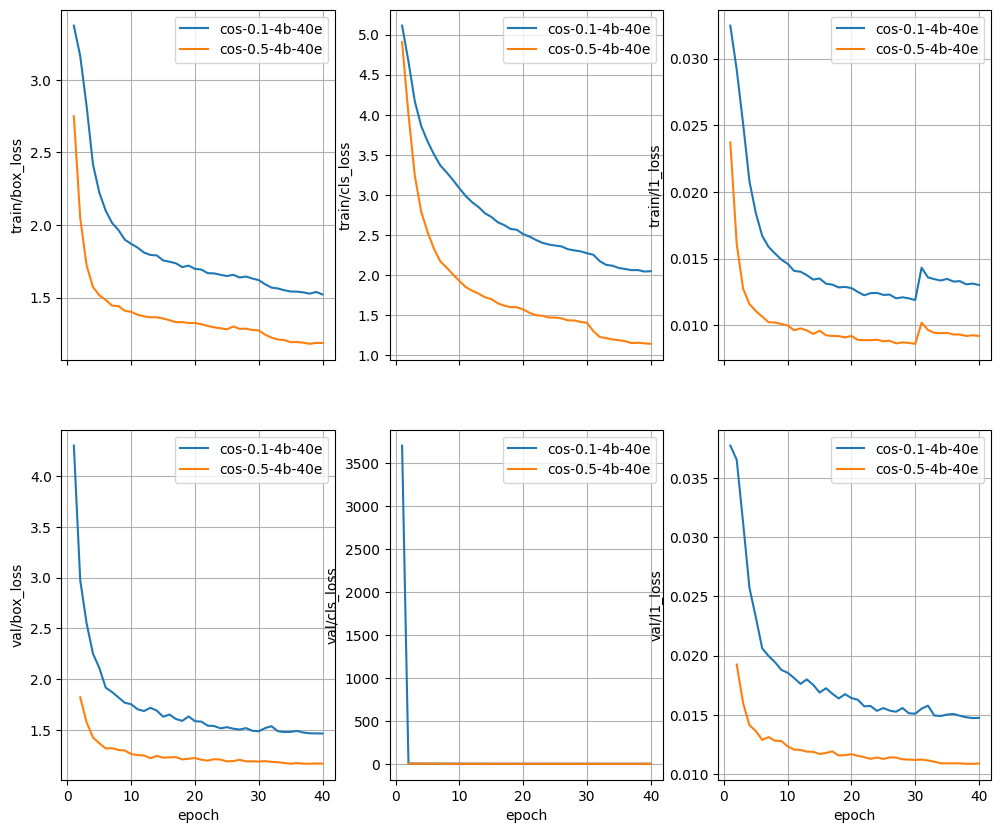

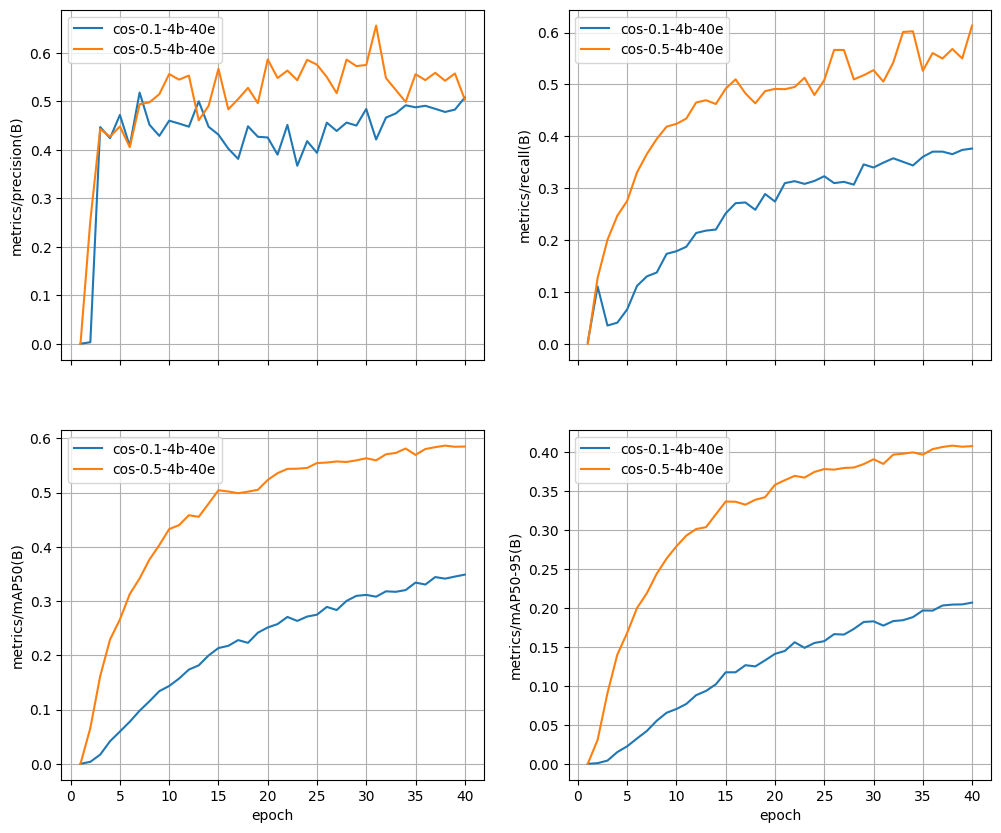

In [7]:
compare_runs(
     'cos-0.1-4b-40e',
    # 'cos-0.01-4b-40e',
    'cos-0.5-4b-40e',
#     'linear-0.5-4b-10e'
    )

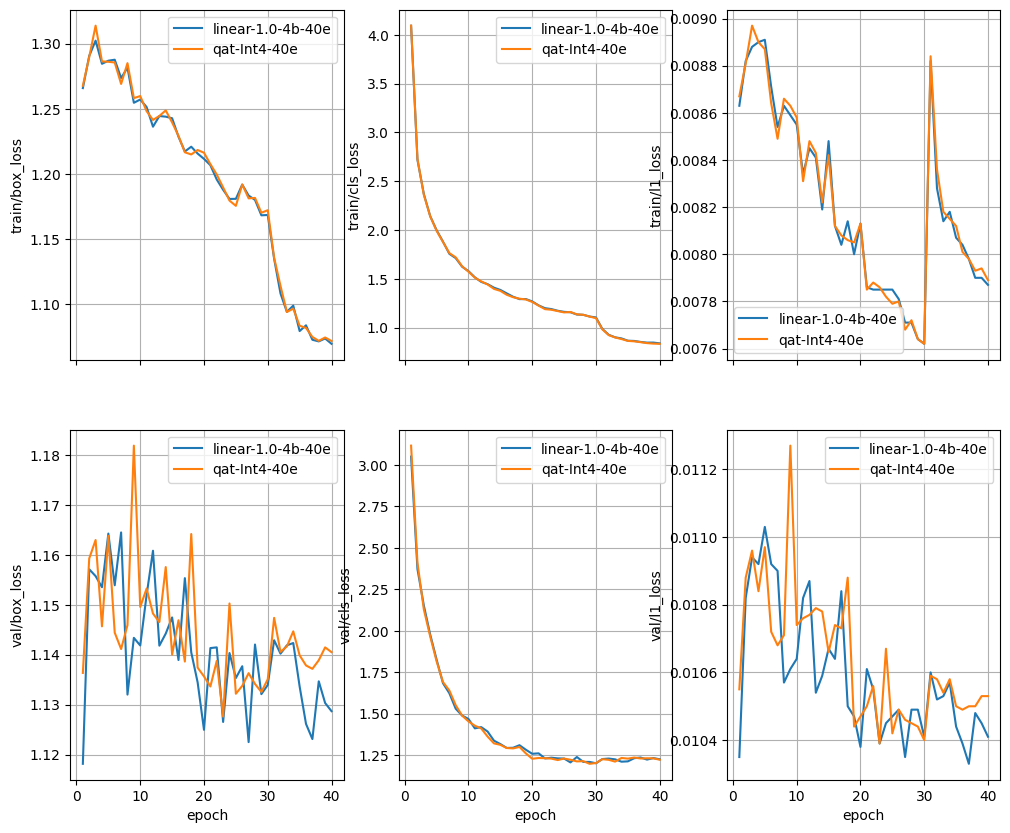

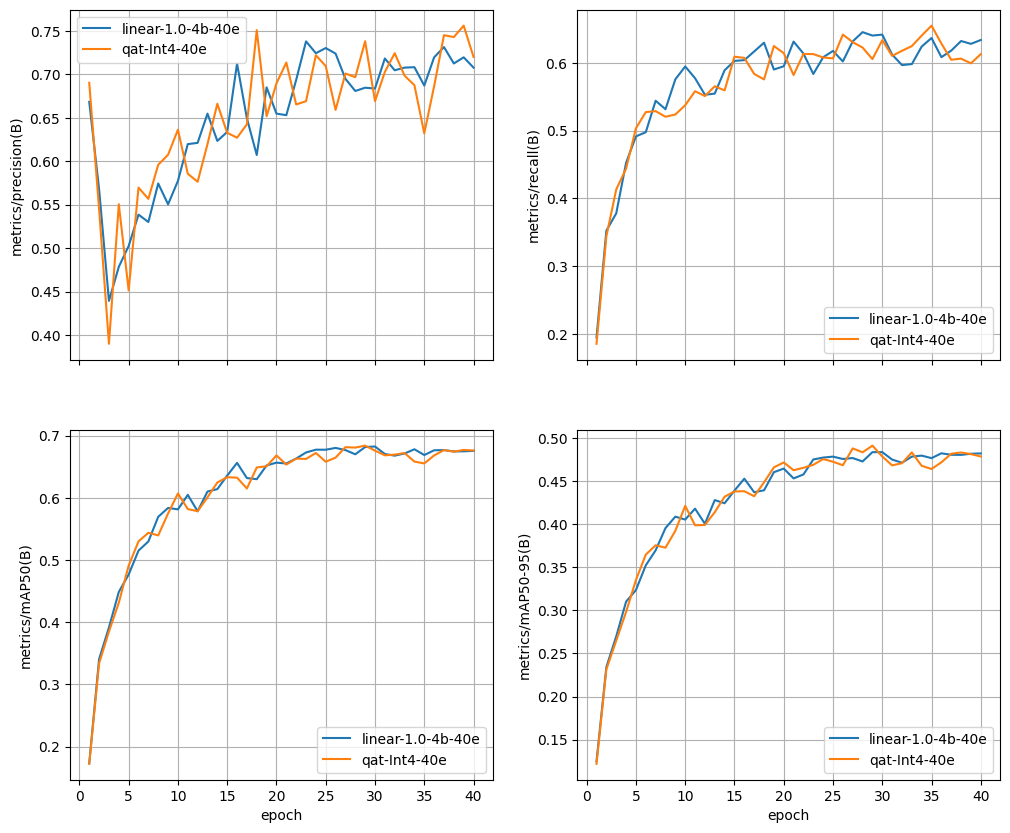

In [5]:
compare_runs(
     'linear-1.0-4b-40e',
    # 'cos-0.01-4b-40e',
    'qat-Int4-40e',
#     'linear-0.5-4b-10e'
    )

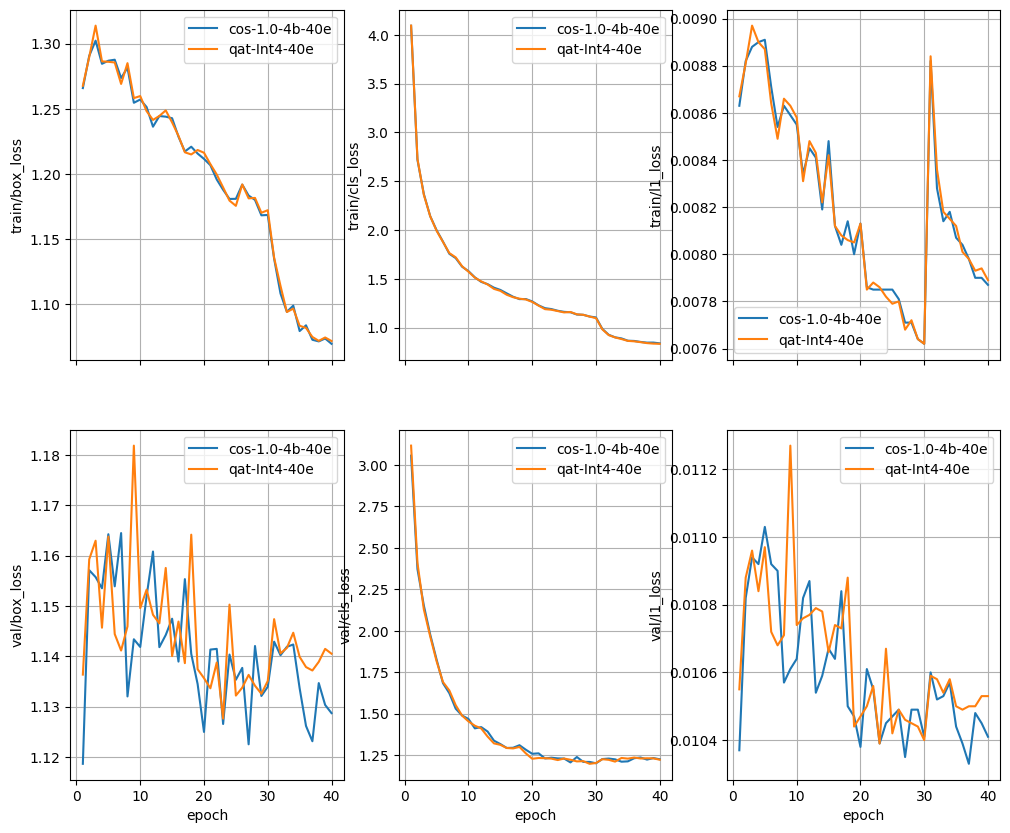

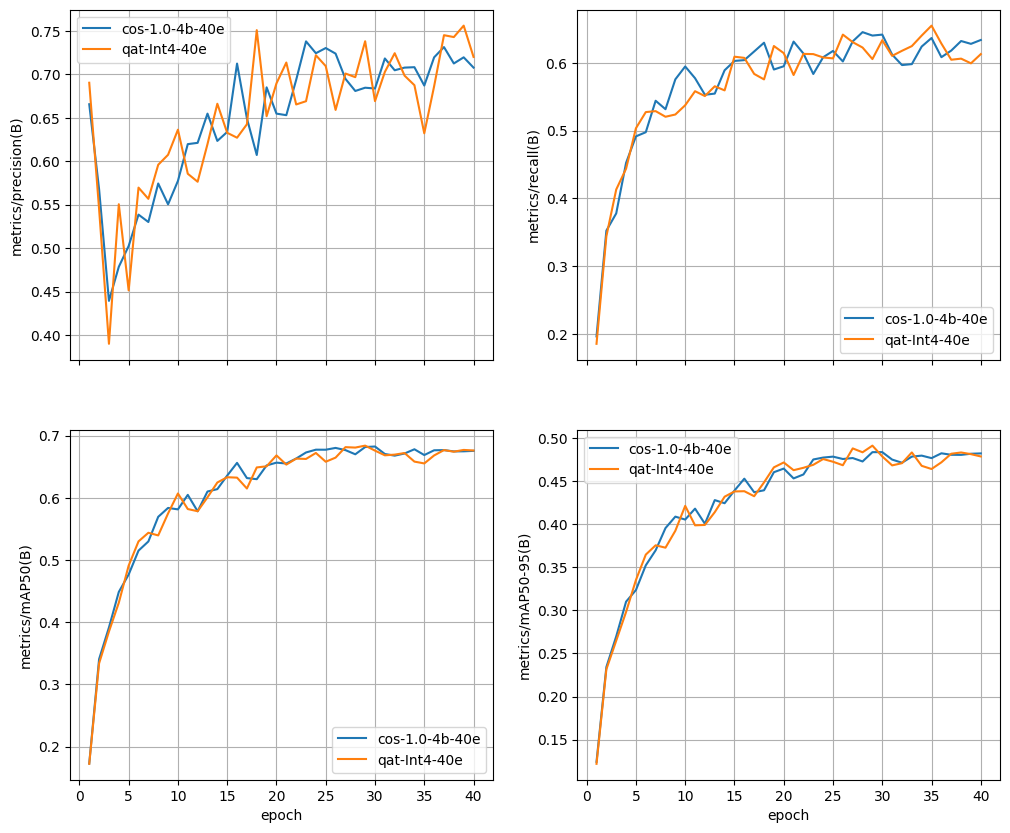

In [8]:
compare_runs(
     'cos-1.0-4b-40e',
    # 'cos-0.01-4b-40e',
    'qat-Int4-40e',
#     'linear-0.5-4b-10e'
    )

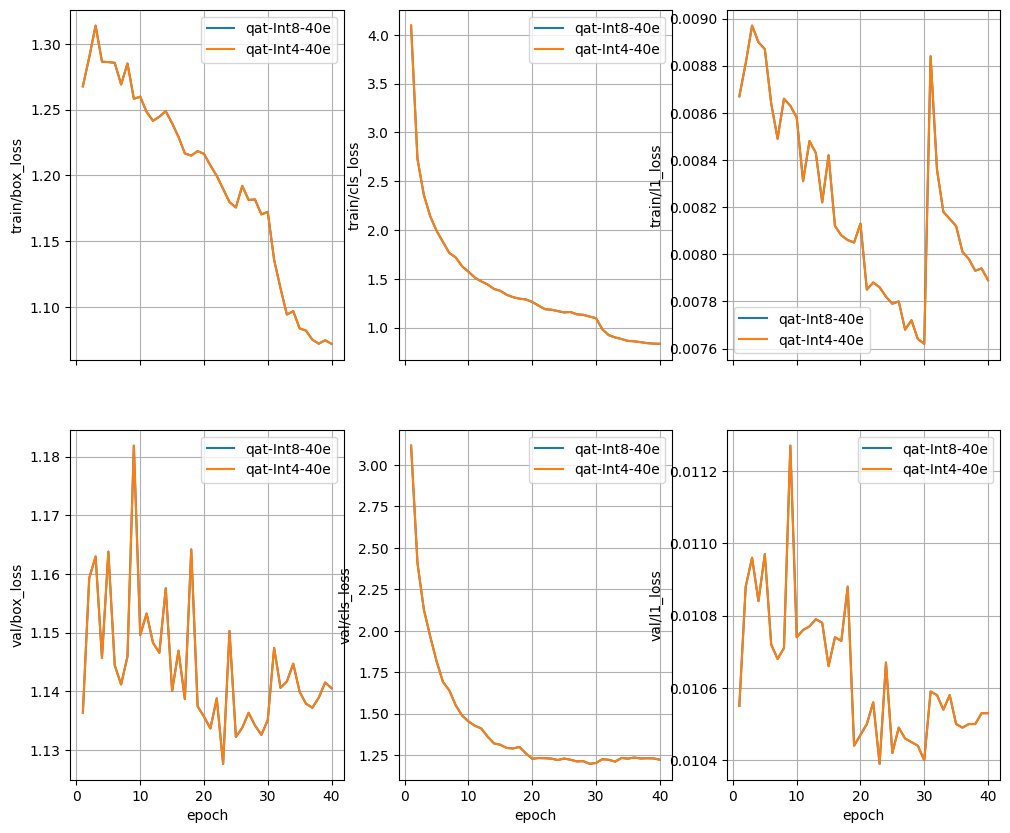

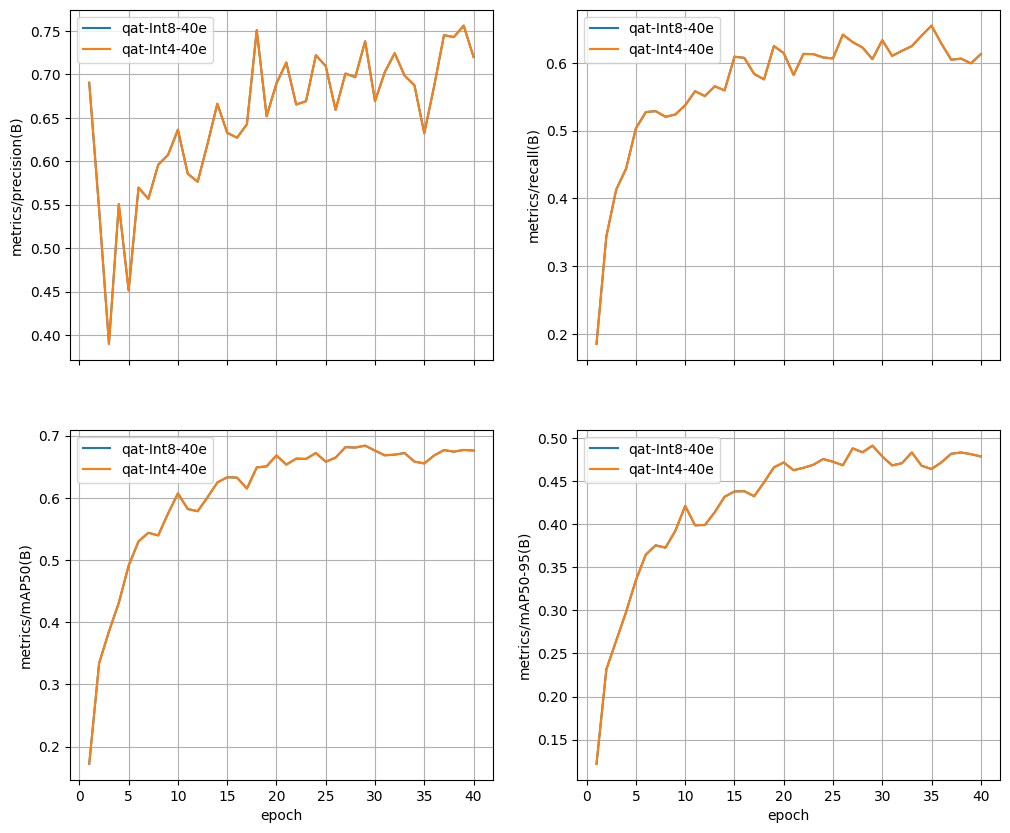

In [7]:
compare_runs(
     'qat-Int8-40e',
    # 'cos-0.01-4b-40e',
    'qat-Int4-40e',
#     'linear-0.5-4b-10e'
    )

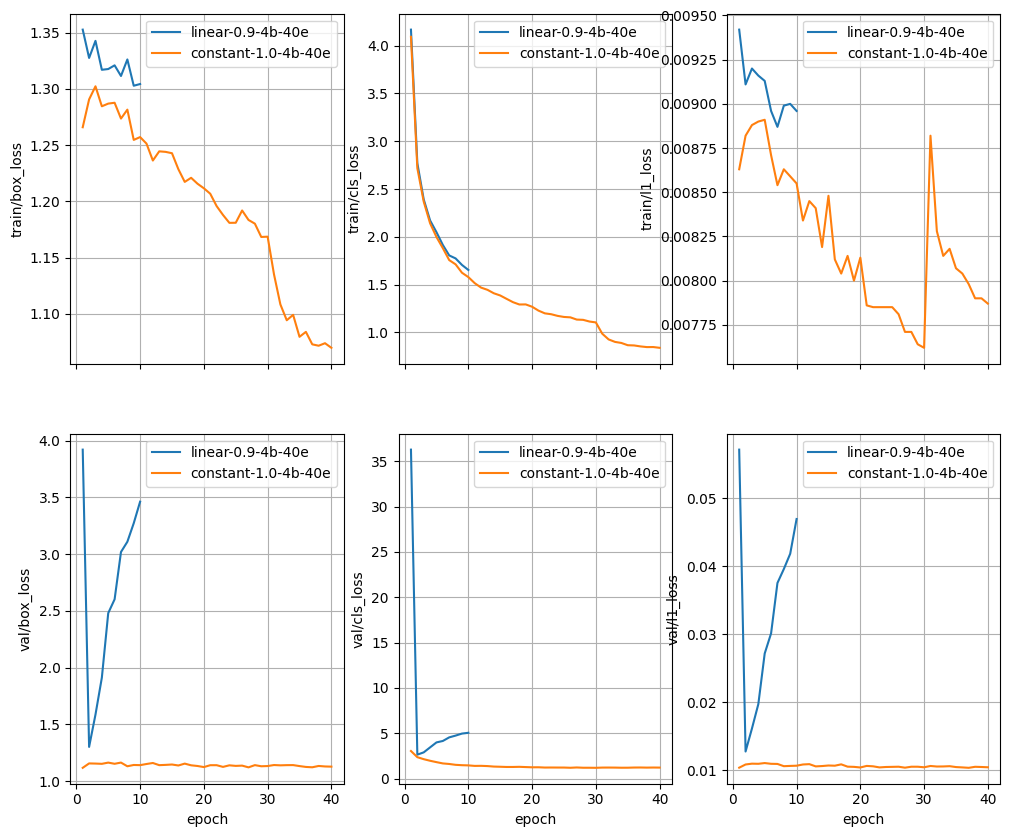

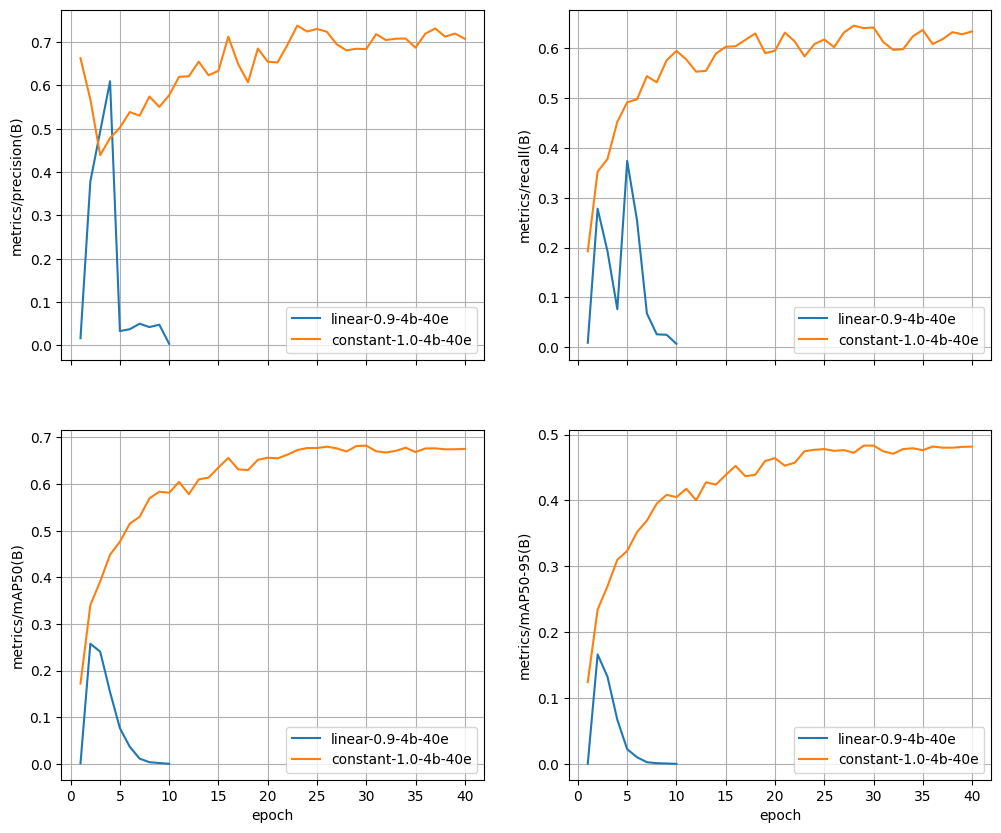

In [14]:
compare_runs(
    'linear-0.9-4b-40e',
    'constant-1.0-4b-40e'
    #  'qat-Int8-40e',
    # 'cos-0.01-4b-40e',
    # 'qat-Int4-40e',
#     'linear-0.5-4b-10e'
    )

# Activation Gathering

In [55]:
from ultralytics import YOLO 

model = YOLO("yolo26n.pt")

In [56]:
GATHERING_PARAMS = [
    'model.model.0.conv.weight',
    'model.model.23.one2one_cv3.2.1.1.conv.weight'
]

In [ ]:
import torch 
from dataclasses import dataclass
from functools import partial 
from pathlib import Path

@dataclass
class Controller:
    is_active: bool
    epoch: int

def add_grad_gathering(model:torch.nn.Module, parameters, controller, path):
    path = Path(path)
    def save_grad(grad, parameter_name, path, controller):
            print('###########')
            full_path = path / parameter_name 
            full_path.mkdir(exist_ok=True, parents=True)
            full_path = full_path/ f'{controller.epoch}.pt'
            torch.save(grad, full_path)
            

    for parameter_name in parameters:
        
        p = model.get_parameter(parameter_name)
        p.requires_grad = True
        p.register_post_accumulate_grad_hook(partial(save_grad, parameter_name=parameter_name, path=path, controller=controller))

def hook_yolo(model, path, parameters):
    controller = Controller(False, 0)
    add_grad_gathering(model, parameters, controller, path)
    def epoch_start(*args, **kwargs):
        controller.epoch += 1
        controller.is_active = True

    # def on_train_batch_end(*args, **kwargs):
    #     controller.is_active = True
    model.add_callback('on_train_epoch_start', epoch_start)
    # model.add_callback('on_train_batch_end', on_train_batch_end)


hook_yolo(model, '/home/leostre/Рабочий стол/SoftStairs-QAT/runs/grads', GATHERING_PARAMS)



In [53]:
model.train(epochs=2, imgsz=640)

New https://pypi.org/project/ultralytics/8.4.108 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.107 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 15832MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0, 16, 17, 20, 25, 58])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x77cf940fead0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,